In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data = pd.read_csv("AusApparalSales4thQrt2020[1].csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [4]:
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [5]:
# 1. Identity the type of data for each column (Numerical, categorical, ordinal and purestring)
# #   Column           Non-Null Count  Dtype
# ---  ------           --------------  -----
#  0   Date    7560 non-null   object -------NUmerical (Contin)
#  1   Time    7560 non-null   object--------Categorical
#  2   State   7560 non-null   object -------categorical
#  3   Group   7560 non-null   object -------Categorical
#  4   Unit    7560 non-null   int64  -------Numerical  (cont)
#  5   Sales   7560 non-null   int64  -------Numerical  (cont)

 Cheking for missing and incorrect values

In [7]:
data.isna().sum()

,0
Date,0
Time,0
State,0
Group,0
Unit,0
Sales,0


As the values are zeroes , we can conclude that there are no missung values in the dataset

In [9]:
# Stripping is done remove any leading spaces from categorical columns
# It helps in preventing incorrect grouping, duplicate categories etc

Stripping is done remove any leading spaces from categorical columns

 It helps in preventing incorrect grouping, duplicate categories etc


In [10]:
data["State"] = data["State"].str.strip()
data['Group'] = data['Group'].str.strip()
data['Time'] = data['Time'].str.strip()

In [11]:
data["Date"] = pd.to_datetime(data["Date"])

In [12]:
data.duplicated().sum()

np.int64(0)

As there are no Duplicates in The records and the variables we can skip the step

 That is there no need for removal or filling of any values.

Normalization of Sales and Unit Columns ( MIN-MAX Normalization ) :

In [15]:
data["Sales_Normalized"] = (data["Sales"] - data["Sales"].min()) / (data["Sales"].max() - data["Sales"].min() )
data["Unit_Normalized"] = (data["Unit"] - data["Unit"].min()) / (data["Unit"].max() - data["Unit"].min() )

In [16]:
data.describe()

,Date,Unit,Sales,Sales_Normalized,Unit_Normalized
count,7560,7560.000000,7560.000000,7560.000000,7560.000000
mean,2020-11-15 04:00:00.000000256,18.005423,45013.558201,0.254054,0.254054
min,2020-10-01 00:00:00,2.000000,5000.000000,0.000000,0.000000
25%,2020-10-23 00:00:00,8.000000,20000.000000,0.095238,0.095238
50%,2020-11-15 12:00:00,14.000000,35000.000000,0.190476,0.190476
75%,2020-12-08 00:00:00,26.000000,65000.000000,0.380952,0.380952
max,2020-12-30 00:00:00,65.000000,162500.000000,1.000000,1.000000
std,NaN,12.901403,32253.506944,0.204784,0.204784


As the mean and the 50% values arenot macthing or are not nearby , we can conclude that there could be outliers in the data

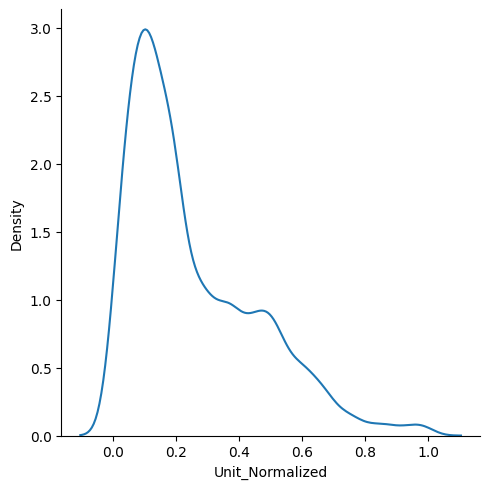

In [18]:
sns.displot(data['Unit_Normalized'],kind='kde')

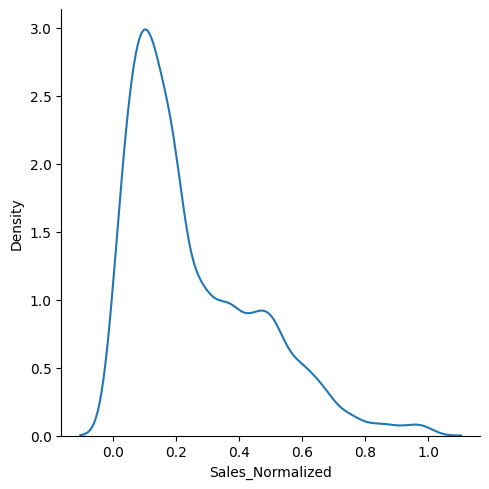

In [19]:
sns.displot(data["Sales_Normalized"] , kind = "kde")

In [20]:
data["Unit"].mean()

np.float64(18.00542328042328)

In [21]:
data["Sales"].mean()

np.float64(45013.5582010582)

In [22]:
# Use Tukeys Method to identify valid range

def outlierDetection(column):
  #Sort the data in asc order

  sorted(column)

  #Calc Q1 and Q3
  Q1,Q3 = np.percentile(column,[25,75])

  #Calc IQR
  IQR = Q3 - Q1

  # Calc Valid Range
  lowerRange = Q1 - (1.5 * IQR)
  upperRange = Q3 + (1.5 * IQR)

  return lowerRange,upperRange

In [23]:
lr,ur = outlierDetection(data["Unit_Normalized"])

In [24]:
lr,ur

(np.float64(-0.3333333333333333), np.float64(0.8095238095238095))

In [25]:
data[(data["Unit_Normalized"]<lr) | (data["Unit_Normalized"]>ur)]

,Date,Time,State,Group,Unit,Sales,Sales_Normalized,Unit_Normalized
5082,2020-12-01,Afternoon,VIC,Women,63,157500,0.968254,0.968254
5083,2020-12-01,Afternoon,VIC,Seniors,62,155000,0.952381,0.952381
5161,2020-12-02,Morning,VIC,Men,56,140000,0.857143,0.857143
5162,2020-12-02,Morning,VIC,Women,59,147500,0.904762,0.904762
5169,2020-12-02,Evening,VIC,Men,64,160000,0.984127,0.984127
...,...,...,...,...,...,...,...,...
7432,2020-12-29,Afternoon,VIC,Kids,65,162500,1.000000,1.000000
7433,2020-12-29,Afternoon,VIC,Men,54,135000,0.825397,0.825397
7437,2020-12-29,Evening,VIC,Men,54,135000,0.825397,0.825397
7515,2020-12-30,Morning,VIC,Seniors,65,162500,1.000000,1.000000


 Outlier analysis was conducted using Tukey’s method. Identified extreme values were retained as they likely represent genuine business fluctuations rather than data errors.

Group By Analysis

In [28]:
# State wise Total revenue :

state_sales = data.groupby('State')['Sales'].sum().sort_values(ascending=False)
state_sales

,Sales
State,
VIC,105565000
NSW,74970000
SA,58857500
QLD,33417500
TAS,22760000
NT,22580000
WA,22152500


In [29]:
#Group wise Total revenue
group_sales = data.groupby('Group')['Sales'].sum().sort_values(ascending=False)
group_sales

,Sales
Group,
Men,85750000
Women,85442500
Kids,85072500
Seniors,84037500


In [30]:
data.head()

,Date,Time,State,Group,Unit,Sales,Sales_Normalized,Unit_Normalized
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873


In [31]:
# State - Group Combined Analysis

state_group_sales = data.groupby(['State','Group'])['Sales'].sum().sort_values(ascending=False)
state_group_sales

State  Group  
VIC    Women      26482500
       Men        26407500
       Kids       26360000
       Seniors    26315000
NSW    Women      19172500
       Men        19022500
       Kids       18587500
       Seniors    18187500
SA     Women      14970000
       Seniors    14717500
       Men        14655000
       Kids       14515000
QLD    Kids        8510000
       Men         8392500
       Women       8325000
       Seniors     8190000
TAS    Kids        5775000
NT     Men         5762500
TAS    Men         5757500
WA     Men         5752500
NT     Kids        5700000
       Women       5652500
TAS    Seniors     5650000
WA     Kids        5625000
TAS    Women       5577500
WA     Seniors     5512500
NT     Seniors     5465000
WA     Women       5262500
Name: Sales, dtype: int64

Descriptive Statistical Analysis

In [33]:
# Sales Analysis

data['Sales'].describe()

,Sales
count,7560.000000
mean,45013.558201
std,32253.506944
min,5000.000000
25%,20000.000000
50%,35000.000000
75%,65000.000000
max,162500.000000


In [34]:
# Manual Metrics :

sales_mean = data['Sales'].mean()
sales_median = data['Sales'].median()
sales_std = data['Sales'].std()
sales_mode = data['Sales'].mode()

In [35]:
sales_mean,sales_median,sales_std,sales_mode

(np.float64(45013.5582010582),
 35000.0,
 32253.506943966317,
 0    22500
 Name: Sales, dtype: int64)

In [36]:
# Unit Statistics

unit_mean = data['Unit'].mean()
unit_median = data['Unit'].median()
unit_std = data['Unit'].std()
unit_mode = data['Unit'].mode()


In [37]:
unit_mean,unit_median,unit_std,unit_mode

(np.float64(18.00542328042328),
 14.0,
 12.901402777586458,
 0    9
 Name: Unit, dtype: int64)

In [38]:
# Highest And Lowest Sales Identification:

# Highest revenue State
highest_state_sales = state_sales.idxmax()
highest_state_sales

'VIC'

In [39]:
# Lowest revenue State
lowest_state_sales = state_sales.idxmin()
lowest_state_sales

'WA'

In [40]:
# Highest Revenue Group
highest_group_sales = group_sales.idxmax()
highest_group_sales

'Men'

In [41]:
# Lowest Revenue Group
lowest_group_sales = group_sales.idxmin()
lowest_group_sales

'Seniors'

Time-Based Reports

Daily Sales Report

In [42]:
daily_report = data.groupby('Date')['Sales'].sum()
daily_report

,Sales
Date,
2020-10-01,3720000
2020-10-02,3715000
2020-10-03,3890000
2020-10-04,3720000
2020-10-05,3862500
...,...
2020-12-26,4715000
2020-12-27,4637500
2020-12-28,4595000


Weekly Sales Report

In [43]:
weekly_report = data.groupby(pd.Grouper(key='Date',freq='W'))['Sales'].sum()
weekly_report

,Sales
Date,
2020-10-04,15045000
2020-10-11,27002500
2020-10-18,26640000
2020-10-25,26815000
2020-11-01,21807500
2020-11-08,20865000
2020-11-15,21172500
2020-11-22,21112500
2020-11-29,21477500


Monthly sales Report


In [44]:
monthly_report = data.groupby(pd.Grouper(key='Date',freq='M'))['Sales'].sum()
monthly_report

/tmp/ipykernel_43975/2310367580.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_report = data.groupby(pd.Grouper(key='Date',freq='M'))['Sales'].sum()


,Sales
Date,
2020-10-31,114290000
2020-11-30,90682500
2020-12-31,135330000


Quarterely Sales Report

In [45]:
quarterly_report = data.groupby(pd.Grouper(key='Date',freq='Q'))['Sales'].sum()
quarterly_report

/tmp/ipykernel_43975/3027805103.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_report = data.groupby(pd.Grouper(key='Date',freq='Q'))['Sales'].sum()


,Sales
Date,
2020-12-31,340302500


Data Visualization


State wise Sales Analysis For Different Demographic Groups

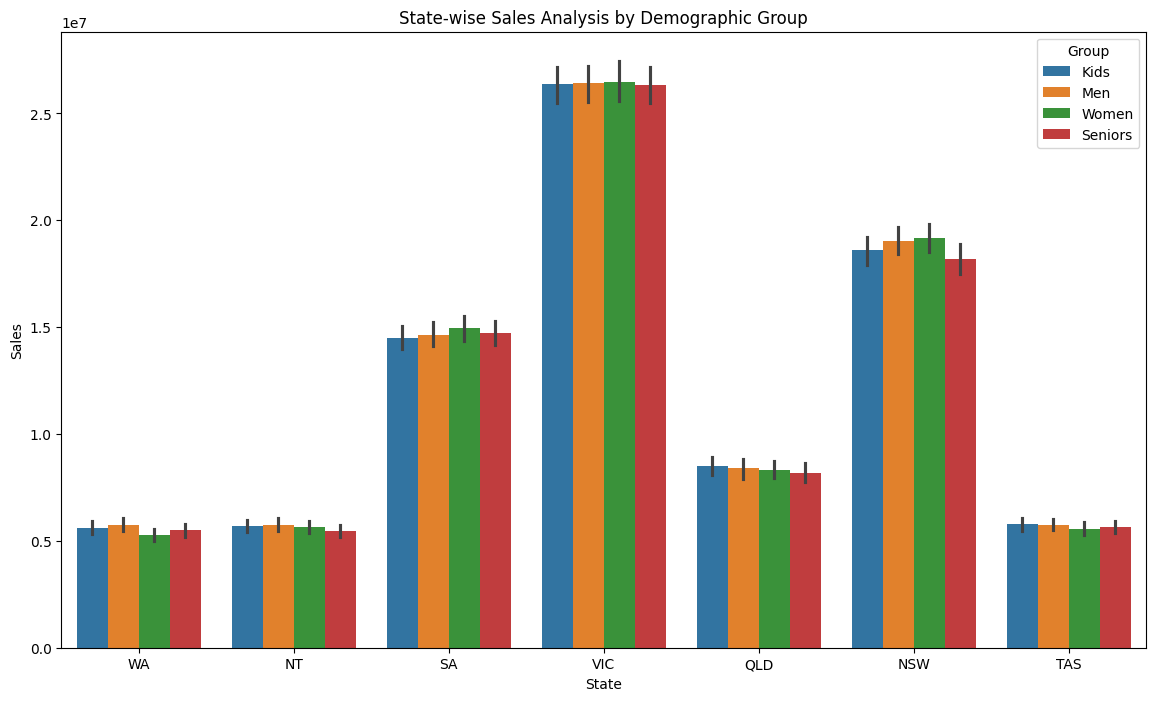

In [46]:
plt.figure(figsize=(14,8))
sns.barplot(data=data, x='State', y='Sales', hue='Group', estimator=sum)
plt.title('State-wise Sales Analysis by Demographic Group')
plt.show()

Group wise Sales Analyis Across Various State

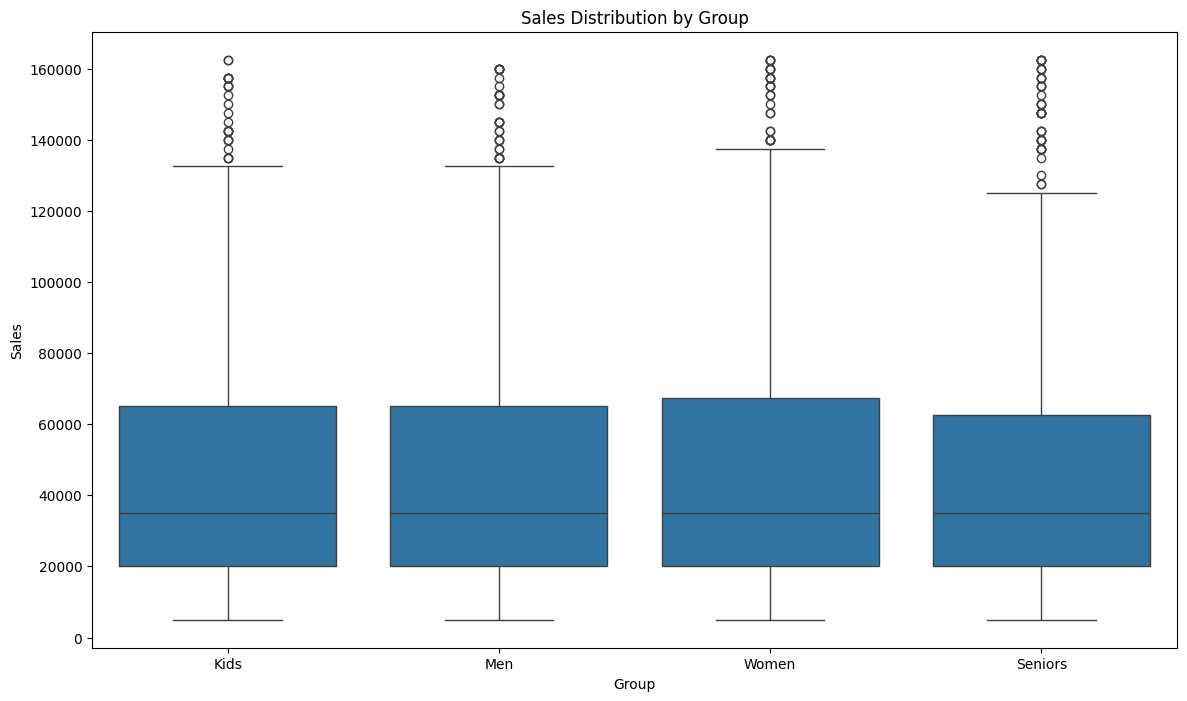

In [47]:
plt.figure(figsize=(14,8))
sns.boxplot(data=data, x='Group', y='Sales')
plt.title('Sales Distribution by Group')
plt.show()

Time-of-the-day analysis

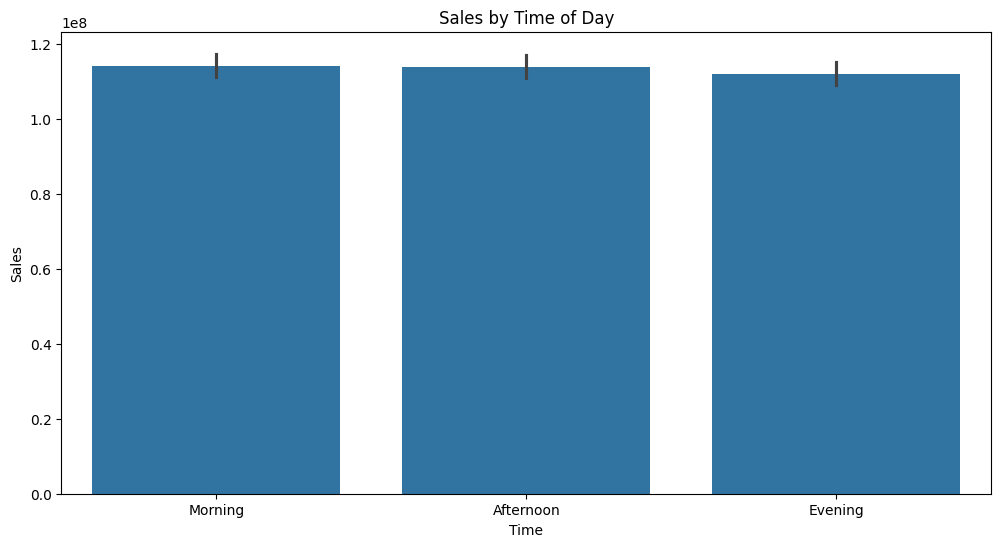

In [48]:
plt.figure(figsize=(12,6))
sns.barplot(data=data, x='Time', y='Sales', estimator=sum)
plt.title('Sales by Time of Day')
plt.show()

Daily Trend

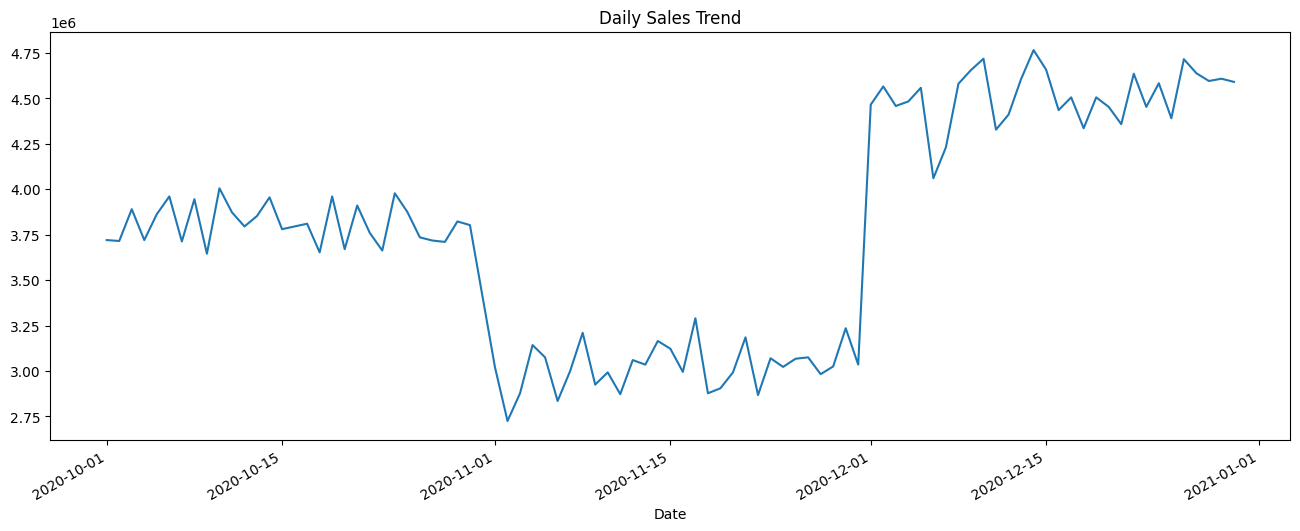

In [49]:
plt.figure(figsize=(16,6))
daily_report.plot()
plt.title('Daily Sales Trend')
plt.show()

Weekly Trend

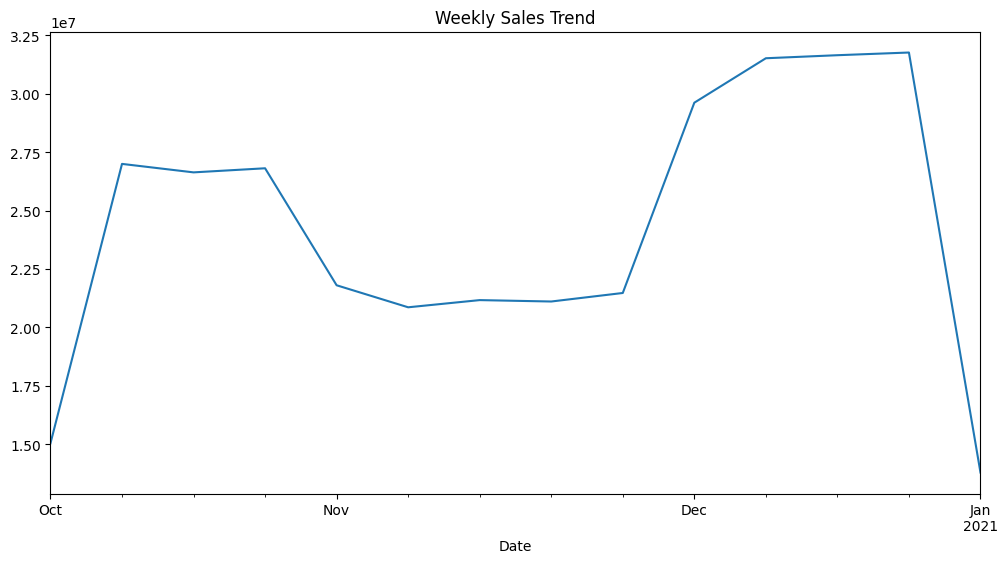

In [50]:
plt.figure(figsize=(12,6))
weekly_report.plot()
plt.title('Weekly Sales Trend')
plt.show()

Monthly Trend

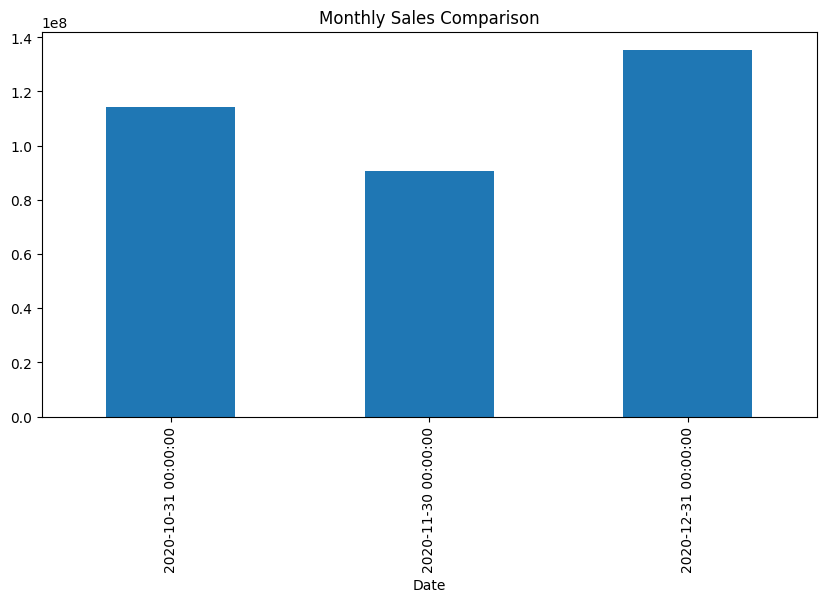

In [51]:
plt.figure(figsize=(10,5))
monthly_report.plot(kind='bar')
plt.title('Monthly Sales Comparison')
plt.show()